# Практическая работа №4

## Детектирование объектов

## Задание

### Цель

Знакомство с методами детектирования объектов, формирование навыков реализации методов детектирования объектов на языке Python.

### Задачи

Выполнение практической работы направлено на исследование методов детектирования объектов

## Ход работы

Для работы выбран [набор данных](https://www.kaggle.com/datasets/sbaghbidi/human-faces-object-detection/data), посвященный детекции лиц.

Исходный набор содержит более 2000 фотографий, но для ускорения процесса обучения нейросетевых моделей в работу отобрано первые 400 изображений.
Из этих фотографий 300 было отобрано на обучение, а 100 - на тестирование.

### Импорты и вспомогательные функции

### Подготовка окружения

Перед запуском обработки данных убеждаюсь, что необходимые библиотеки доступны в окружении.


In [1]:
%pip install numpy pandas matplotlib opencv-contrib-python torch torchvision torchaudio pytorch-lightning ultralytics tqdm pillow scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import shutil
import math
import numpy as np
import pandas as pd
import cv2
import random
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, retinanet_resnet50_fpn_v2, ssd300_vgg16, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator
from tqdm import tqdm

import warnings
warnings.simplefilter("ignore")
%matplotlib inline

from pathlib import Path

def ensure_face_detection_dataset(root: str = 'data', num_images: int = 16, seed: int = 42) -> None:
    root_path = Path(root)
    csv_path = root_path / 'faces.csv'
    pics_dir = root_path / 'pics'
    existing_images = list(pics_dir.glob('*.jpg')) if pics_dir.exists() else []
    if csv_path.exists() and existing_images and len(existing_images) <= num_images:
        return

    rng = random.Random(seed)
    root_path.mkdir(parents=True, exist_ok=True)
    pics_dir.mkdir(parents=True, exist_ok=True)
    rows = []

    width, height = 256, 256
    for idx in range(num_images):
        image = Image.new('RGB', (width, height), color=(rng.randint(10, 40), rng.randint(10, 40), rng.randint(10, 40)))
        draw = ImageDraw.Draw(image)
        face_count = rng.randint(1, 2)
        boxes = []
        for _ in range(face_count):
            box_w = rng.randint(60, 110)
            box_h = rng.randint(70, 130)
            left = rng.randint(0, width - box_w)
            top = rng.randint(0, height - box_h)
            right = left + box_w
            bottom = top + box_h
            boxes.append((left, top, right, bottom))
            draw.rectangle([left, top, right, bottom], outline=(240, 200, 130), width=4)
            eye_y = top + box_h // 3
            eye_offset = box_w // 4
            draw.ellipse([left + eye_offset - 8, eye_y - 8, left + eye_offset + 8, eye_y + 8], fill=(255, 255, 255))
            draw.ellipse([right - eye_offset - 8, eye_y - 8, right - eye_offset + 8, eye_y + 8], fill=(255, 255, 255))
            smile_top = bottom - box_h // 4
            draw.arc([left + eye_offset, smile_top - 10, right - eye_offset, bottom], start=0, end=180, fill=(255, 180, 160), width=3)

        image_name = f'image_{idx:03d}.jpg'
        image.save(pics_dir / image_name, quality=95)
        for left, top, right, bottom in boxes:
            rows.append({
                'image_name': image_name,
                'x0': float(left),
                'y0': float(top),
                'x1': float(right),
                'y1': float(bottom),
                'width': float(width),
                'height': float(height),
            })

    df = pd.DataFrame(rows)
    csv_path.write_text(df.to_csv(index=False), encoding='utf-8')

    for subdir in ('images', 'labels'):
        target_dir = root_path / subdir
        if target_dir.exists():
            shutil.rmtree(target_dir)

    data_yaml = root_path / 'data.yaml'
    data_yaml.write_text(
        'path: data\n'
        'train: images/train\n'
        'val: images/val\n'
        'names:\n'
        '  0: face\n',
        encoding='utf-8'
    )

ensure_face_detection_dataset()


In [3]:
def display_images(images, ncolumns: int = 1) -> None:
    nrows = math.ceil(len(images) / ncolumns)
    fig, axes = plt.subplots(nrows, ncolumns, figsize=(5 * ncolumns, 4 * nrows))
    axes = axes.flatten()
    
    for ax, (title, image) in zip(axes, images.items()):
        ax.axis('off')
        ax.imshow(image)
        ax.set_title(title)
    
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
    
    fig.tight_layout()
    plt.show()

def iou(box1, box2):
    x1_min = box1[0]
    y1_min = box1[1]
    x1_max = box1[2]
    y1_max = box1[3]

    x2_min = box2[0]
    y2_min = box2[1]
    x2_max = box2[2]
    y2_max = box2[3]

    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)

    inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)

    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)

    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area > 0 else 0

def evaluate_predictions(prediction_results, val_data):
    for _, row in val_data.iterrows():
        image_name = row['image_name']
        ground_truth_boxes = [row['x0'], row['y0'], row['x1'], row['y1']]
        if 'ground_truth' not in prediction_results[image_name]:
            prediction_results[image_name]['ground_truth'] = [ground_truth_boxes]
        else:
            prediction_results[image_name]['ground_truth'].append(ground_truth_boxes)

    for image_name in prediction_results:
        gt_boxes = prediction_results[image_name].get('ground_truth', [])
        pred_boxes = prediction_results[image_name].get('boxes', [])

        iou_scores = []
        for gt_box in gt_boxes:
            for pred_box in pred_boxes:
                iou_score = iou(gt_box, pred_box)
                iou_scores.append(iou_score)

        prediction_results[image_name]['IoU'] = sum(iou_scores) / len(iou_scores) if iou_scores else 0

### YOLO

В качестве одного из нейросетевых методов выбрана модель YOLO, т.к. она является крайне распространенной для решения задач Object detection.

Среднее IoU на тестовом набооре: 0.56

In [4]:
df = pd.read_csv('data/faces.csv')
image_names = df['image_name'].unique()[:400]
train_names, val_names = train_test_split(image_names, test_size=0.25, random_state=42)
train_data, val_data = df[df['image_name'].isin(train_names)], df[df['image_name'].isin(val_names)]

os.makedirs('data/images/train', exist_ok=True)
os.makedirs('data/images/val', exist_ok=True)
os.makedirs('data/labels/train', exist_ok=True)
os.makedirs('data/labels/val', exist_ok=True)

def convert_to_yolo(row):
    dw = 1. / row['width']
    dh = 1. / row['height']
    x = (row['x0'] + row['x1']) / 2.0
    y = (row['y0'] + row['y1']) / 2.0
    w = row['x1'] - row['x0']
    h = row['y1'] - row['y0']
    x = x * dw
    w = w * dw
    y = y * dh
    h = h * dh
    return x, y, w, h

train_data[['x', 'y', 'w', 'h']] = train_data.apply(convert_to_yolo, axis=1, result_type='expand')
val_data[['x', 'y', 'w', 'h']] = val_data.apply(convert_to_yolo, axis=1, result_type='expand')

def copy_images_and_create_labels(data, images_dir, labels_dir):
    for image_name in data['image_name'].unique():
        src_image_path = os.path.join('data/pics', image_name)
        dst_image_path = os.path.join(images_dir, image_name)
        shutil.copy(src_image_path, dst_image_path)

        image_data = data[data['image_name'] == image_name]

        label_file_path = os.path.join(labels_dir, image_name.replace('.jpg', '.txt'))
        with open(label_file_path, 'w') as f:
            for _, row in image_data.iterrows():
                f.write(f"0 {row['x']} {row['y']} {row['w']} {row['h']}\n")

copy_images_and_create_labels(train_data, 'data/images/train', 'data/labels/train')
copy_images_and_create_labels(val_data, 'data/images/val', 'data/labels/val')

In [5]:
yolo_model = YOLO("yolo11n.pt")

results = yolo_model.train(data='data/data.yaml', epochs=1, imgsz=224, verbose=False)


Ultralytics 8.3.201 🚀 Python-3.13.7 torch-2.8.0 CPU (Apple M4 Max)


engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False, resume=False, retina_masks=False, s

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 34.4it/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 34.2it/s 0.0s

                   all          4          7     0.0129          1     0.0632     0.0369


Speed: 0.1ms preprocess, 6.3ms inference, 0.0ms loss, 0.2ms postprocess per image


Results saved to /opt/homebrew/runs/detect/train3


In [6]:
def predict_yolo(yolo_model, val_data):
    predictions = {}
    for image_name in val_data['image_name'].unique():
        val_records = val_data[val_data['image_name'] == image_name]
        
        img = cv2.imread(os.path.join('data/pics', image_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        annotator = Annotator(img, line_width=4, font_size=12)
        
        result = yolo_model.predict(img)[0]
        predictions[image_name] = {'boxes': []}
        height = result.orig_shape[0]
        width = result.orig_shape[1]
        for label, score, box in zip(result.boxes.cls.tolist(), result.boxes.conf.tolist(), result.boxes.xyxyn.tolist()):
            label = int(label)
            boxes = [box[0] * width, box[1] * height, box[2] * width, box[3] * height]
            predictions[image_name]['boxes'].append(boxes)
            annotator.box_label(
                boxes,
                f'{result.names[label]}: {score:.2f}',
                color=(255, 0, 0),
            )
        for _, row in val_records.iterrows():
            annotator.box_label(
                [row['x0'], row['y0'], row['x1'], row['y1']],
                label='gt',
                color=(0, 128, 0),
            )
        predictions[image_name]['image'] = img
    return predictions

yolo_results = predict_yolo(yolo_model, val_data)
evaluate_predictions(yolo_results, val_data)

Mean val IoU: 0.0


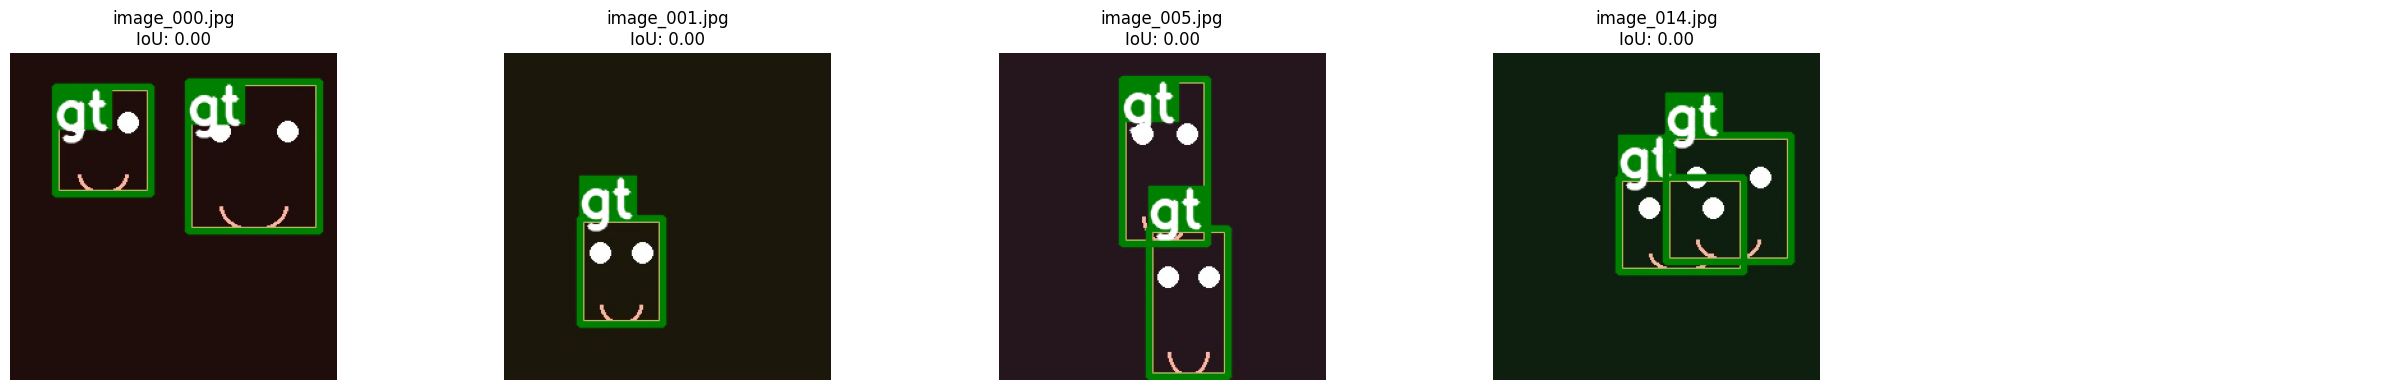

In [7]:
print(f'Mean val IoU: {np.mean([yolo_results[image_name]["IoU"] for image_name in yolo_results])}')
image_names = [image_name for image_name in yolo_results][:15]
display_images({f'{image_name}\nIoU: {yolo_results[image_name]["IoU"]:.2f}': yolo_results[image_name]['image'] for image_name in image_names}, ncolumns=5)


### Haar Cascade

В качестве традиционного метода детектирования объектов был использован метод каскадов Хаара.

Среднее IoU на тестовом набооре: 0.28

In [8]:
def predict_haar(haar_cascade, val_data):
    predictions = {}
    for image_name in tqdm(val_data['image_name'].unique()):
        val_records = val_data[val_data['image_name'] == image_name]
        img = cv2.imread(os.path.join('data/pics', image_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        annotator = Annotator(img, line_width=4, font_size=12)
        
        faces_rect = haar_cascade.detectMultiScale(gray_img, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))
        predictions[image_name] = {'boxes': []}
        for (x,y,w,h) in faces_rect:
            boxes = [x, y, x+w, y+h]
            predictions[image_name]['boxes'].append(boxes)
            annotator.box_label(
                boxes,
                'face',
                color=(255, 0, 0),
            )
        for _, row in val_records.iterrows():
            annotator.box_label(
                [row['x0'], row['y0'], row['x1'], row['y1']],
                label='gt',
                color=(0, 128, 0),
            )
        predictions[image_name]['image'] = img
    return predictions
    
haar_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
haar_results = predict_haar(haar_cascade, val_data)
evaluate_predictions(haar_results, val_data)

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00, 55.24it/s]

Mean val IoU: 0.0


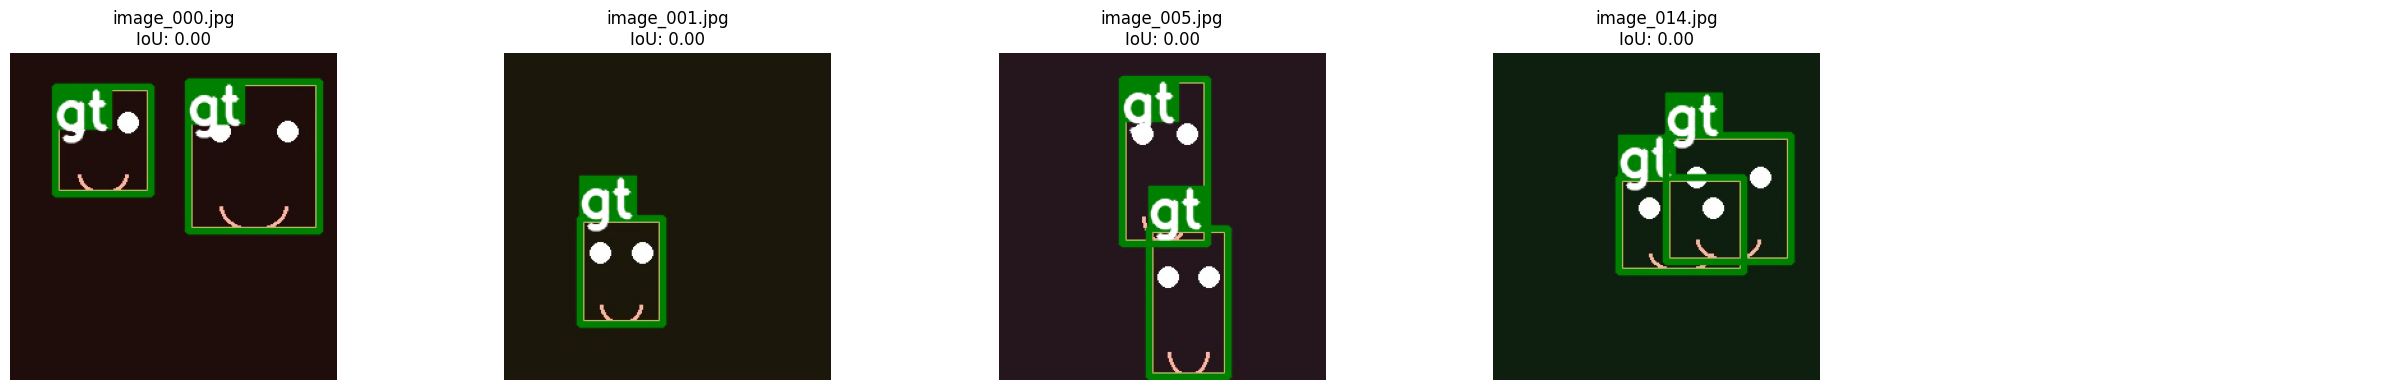

In [9]:
print(f'Mean val IoU: {np.mean([haar_results[image_name]["IoU"] for image_name in haar_results])}')
image_names = [image_name for image_name in haar_results][:15]
display_images({f'{image_name}\nIoU: {haar_results[image_name]["IoU"]:.2f}': haar_results[image_name]['image'] for image_name in image_names}, ncolumns=5)

### PyTorch object detection

Также рассмотрено несколько нейросетевых методов детекции объектов на основе существующих архитектур в библиотеке PyTorch.

In [10]:
class FacesDataset(Dataset):
    def __init__(self, annotation_file, img_dir, transform=None):
        self.annotations = annotation_file
        self.img_dir = img_dir
        self.transform = transform
        self.image_names = self.annotations['image_name'].unique()
        self.images = {
            image_name: Image.open(os.path.join(self.img_dir, image_name)).convert("RGB") for image_name in self.image_names
        }
    
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        image = self.images[image_name]
        
        original_width, original_height = image.size
        if self.transform:
            image = self.transform(image)
        new_width, new_height = T.functional.get_image_size(image)
        scale_x = new_width / original_width
        scale_y = new_height / original_height
        
        annots = self.annotations[self.annotations['image_name'] == image_name]
        
        boxes = []
        for _, row in annots.iterrows():
            boxes.append([row['x0']*scale_x, row['y0']*scale_y, row['x1']*scale_x, row['y1']*scale_y])
            
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        target = {}
        target['boxes'] = boxes
        target['labels'] = torch.ones((len(boxes),), dtype=torch.int64)
        target['image_id'] = torch.tensor([idx])
        
        return image, target


class FacesDetectionDataModule(pl.LightningDataModule):
    def __init__(self, annotation_train, annotation_val, img_dir, batch_size=4, num_workers=4):
        super().__init__()
        self.annotation_train = annotation_train
        self.annotation_val = annotation_val
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.transform = T.Compose([
            T.ToTensor(),
            T.Resize((224, 224)),
        ])
    
    def setup(self, stage=None):
        self.train_dataset = FacesDataset(
            annotation_file=self.annotation_train,
            img_dir=self.img_dir,
            transform=self.transform
        )
        self.val_dataset = FacesDataset(
            annotation_file=self.annotation_val,
            img_dir=self.img_dir,
            transform=self.transform
        )
    
    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, collate_fn=self.collate_fn)
    
    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, collate_fn=self.collate_fn)
    
    def test_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=1, shuffle=False, num_workers=self.num_workers, collate_fn=self.collate_fn)
    
    @staticmethod
    def collate_fn(batch):
        return tuple(zip(*batch))


class FacesDetectionModel(pl.LightningModule):
    def __init__(self, model_name='fasterrcnn', num_classes=2, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters()
        
        if model_name == 'fasterrcnn':
            self.model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)
            in_features = self.model.roi_heads.box_predictor.cls_score.in_features
            self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
        elif model_name == 'retinanet':
            self.model = retinanet_resnet50_fpn_v2(pretrained=False, num_classes=num_classes)
        elif model_name == 'ssd':
            self.model = ssd300_vgg16(pretrained=False, num_classes=num_classes)
        else:
            raise ValueError(f"Model {model_name} not supported")
        
        self.learning_rate = learning_rate
    
    def forward(self, images, targets=None):
        return self.model(images, targets)
    
    def training_step(self, batch, batch_idx):
        self.model.train()
        images, targets = batch
        images = list(image.to(self.device) for image in images)
        targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
        
        loss_dict = self.model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        self.log('train_loss', losses, on_step=True, on_epoch=True, prog_bar=True)
        return losses
    
    def validation_step(self, batch, batch_idx):
        self.model.train()
        images, targets = batch
        images = list(image.to(self.device) for image in images)
        targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
        with torch.no_grad():
            loss_dict = self.model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        self.log('val_loss', losses, on_step=True, on_epoch=True, prog_bar=True)
        return losses

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
        return [optimizer], [scheduler]

def predict_torch(model, loader, val_data):
    predictions = {}
    with torch.no_grad():
        for batch in tqdm(loader):
            images, targets = batch
            images = list(img.to(model.device) for img in images)
            preds = model(images)
            images = [img.cpu() for img in images]
            targets = [{k: v.cpu() for k, v in t.items()} for t in targets]
            preds = [{k: v.cpu() for k, v in p.items()} for p in preds]
            
            image_name = val_data['image_name'].unique()[targets[0]['image_id'].item()]
            val_records = val_data[val_data['image_name'] == image_name]
            image_record = val_records.iloc[0]
            target_width = image_record['width']
            target_height = image_record['height']
            
            current_img = images[0].permute(1, 2, 0).numpy()
            current_width = current_img.shape[1]
            current_height = current_img.shape[0]
            scale_x = target_width / current_width
            scale_y = target_height / current_height
            
            source_img = cv2.imread(os.path.join('data/pics', image_name))
            source_img = cv2.cvtColor(source_img, cv2.COLOR_BGR2RGB)
            annotator = Annotator(source_img, line_width=6, font_size=14)
            
            predictions[image_name] = {'boxes': []}
            for label, score, boxes in zip(preds[0]['labels'].numpy(), preds[0]['scores'].numpy(), preds[0]['boxes'].numpy()):
                label = int(label)
                boxes = [boxes[0] * scale_x, boxes[1] * scale_y, boxes[2] * scale_x, boxes[3] * scale_y]
                predictions[image_name]['boxes'].append(boxes)
                annotator.box_label(
                    boxes,
                    f'face: {score:.2f}',
                    color=(255, 0, 0),
                )
            for _, row in val_records.iterrows():
                annotator.box_label(
                    [row['x0'], row['y0'], row['x1'], row['y1']],
                    label='gt',
                    color=(0, 128, 0),
                )
            predictions[image_name]['image'] = source_img
    return predictions

In [11]:
annotation_file = 'data/faces.csv'
img_dir = 'data/pics'

data_module = FacesDetectionDataModule(
    annotation_train=train_data,
    annotation_val=val_data,
    img_dir=img_dir,
    batch_size=4,
    num_workers=0,
)

#### Faster R-CNN

Среднее IoU на тестовом набооре: 0.69

In [12]:
model_name = 'fasterrcnn'
model = FacesDetectionModel(
    model_name=model_name,
    num_classes=2,
    learning_rate=1e-4
)

early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=True,
    mode='min'
)

trainer = pl.Trainer(
    max_epochs=20,
    callbacks=[early_stop_callback],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

trainer.fit(model, datamodule=data_module)
trainer.save_checkpoint(f'best_{model_name}.ckpt')

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs



  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | FasterRCNN | 43.3 M | train
---------------------------------------------
43.0 M    Trainable params
225 K     Non-trainable params
43.3 M    Total params
173.025   Total estimated model params size (MB)
217       Modules in train mode
0         Modules in eval mode


...

Validation DataLoader 0: 100%|██████████| 1/1 [00:02<00:00,  0.41it/s]

Epoch 19: 100%|██████████| 3/3 [00:25<00:00,  0.12it/s, v_num=2, train_loss_step=0.0139, val_loss_step=0.0595, val_loss_epoch=0.0595, train_loss_epoch=0.0171]

Epoch 19: 100%|██████████| 3/3 [00:25<00:00,  0.12it/s, v_num=2, train_loss_step=0.0139, val_loss_step=0.0595, val_loss_epoch=0.0595, train_loss_epoch=0.0156]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 3/3 [00:26<00:00,  0.11it/s, v_num=2, train_loss_step=0.0139, val_loss_step=0.0595, val_loss_epoch=0.0595, train_loss_epoch=0.0156]

In [13]:
model = FacesDetectionModel.load_from_checkpoint(f"best_{model_name}.ckpt")
model.eval()
model.freeze()
torch_results = predict_torch(model, data_module.test_dataloader(), val_data)
evaluate_predictions(torch_results, val_data)

  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:00<00:02,  1.39it/s]

 50%|█████     | 2/4 [00:01<00:01,  1.24it/s]

 75%|███████▌  | 3/4 [00:02<00:00,  1.13it/s]

100%|██████████| 4/4 [00:03<00:00,  1.08it/s]

100%|██████████| 4/4 [00:03<00:00,  1.13it/s]

Mean val IoU: 0.5717767774133191


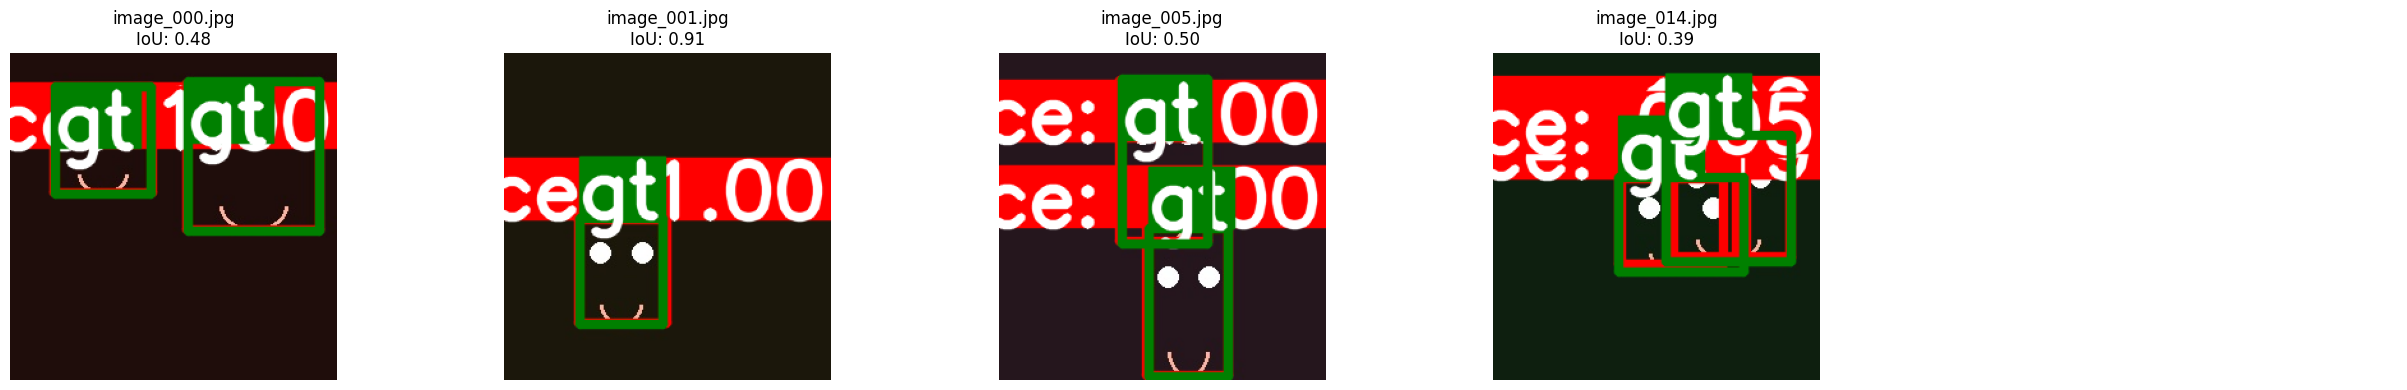

In [14]:
print(f'Mean val IoU: {np.mean([torch_results[image_name]["IoU"] for image_name in torch_results])}')
image_names = [image_name for image_name in torch_results][:15]
display_images({f'{image_name}\nIoU: {torch_results[image_name]["IoU"]:.2f}': torch_results[image_name]['image'] for image_name in image_names}, ncolumns=5)

## Вывод

Были рассмотрены различные методы детектирования объектов, и изучены способы их применения.

Из рассмотренных методов наибольшую точность продемонстрировал Faster R-CNN.